In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from utils import load_multi_traj_data
from model import DeepONet
import os
from matplotlib.patches import Ellipse
from tqdm import tqdm

In [5]:
def visualize_ellipsoid(gt_traj, test_traj, Q=None, c=1.0):
	# Perform a PCA on the reshaped data, data is of size (num_traj, traj_length, traj_dim), we can lump all trajectory together into (traj_length, traj_dim)
	reshaped_data = gt_traj.reshape(-1, gt_traj.shape[-1])
	if test_traj is not None:
		pred_traj = test_traj.reshape(-1, test_traj.shape[-1]).detach().cpu().numpy()
 
	print(reshaped_data.shape)
	pca = PCA(n_components=2)
	pca_traj_1 = pca.fit_transform(reshaped_data)
	if test_traj is not None:
		pca_traj_pred = pca.fit_transform(pred_traj)
	U = pca.components_

	if Q is None:
		# If no Q is provided, use the covariance
		Q = np.eye(U.shape[-1])
		c = c ** 2
		
	Q_inv = np.linalg.inv(Q)
	A = np.linalg.inv(U @ Q_inv @ U.T)

	# ----------------------------
	# Extract ellipse parameters from A:
	# The ellipse in PCA space is given by y^T A y = c.
	# Its semi-axis lengths are given by sqrt(c / eigenvalue).
	# The eigenvectors determine the orientation.
	# ----------------------------
	eigvals, eigvecs = np.linalg.eigh(A)
	print(eigvals)
	# Sort eigenvalues and eigenvectors in descending order.
	order = np.argsort(eigvals)[::-1]
	eigvals = eigvals[order]
	eigvecs = eigvecs[:, order]

	# Compute semi-axis lengths (for y^T A y = c)
	# print(eigvals)
	axis_length1 = np.sqrt(c / eigvals[0])
	axis_length2 = np.sqrt(c / eigvals[1])

	# Compute the rotation angle (in degrees) of the ellipse.
	angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

	# ----------------------------
	# Plot the projected ellipsoid in the 2D PCA space.
	# ----------------------------
	fig, ax = plt.subplots(figsize=(10, 10))

	# For a centered ellipsoid, the projected center is U*(x0 - x0)=0.
	ellipse_patch = Ellipse(xy=(0, 0),
							width=2 * axis_length1,   # full axis length in the first direction
							height=2 * axis_length2,  # full axis length in the second direction
							angle=angle,
							edgecolor='red', facecolor='none', lw=2
							)
	ax.add_patch(ellipse_patch)

	# Optionally, plot the PCA-transformed trajectory data for context.
	ax.scatter(pca_traj_1[:, 0], pca_traj_1[:, 1], s=2, alpha=0.3, label="PCA GT")
	if test_traj is not None:
		ax.scatter(pca_traj_pred[:, 0], pca_traj_pred[:, 1], s=2, alpha=0.3, label="PCA Pred")
	ax.set_xlim(-25, 25)
	ax.set_ylim(-25, 25)

	ax.set_xlabel('Component 1')
	ax.set_ylabel('Component 2')
	ax.legend()
	plt.axis('equal')

In [6]:
def rollout_on_test(eval_model, data_x, trunk_scale, test_traj, device):
	eval_model.eval()
	trunk_input = torch.tensor(data_x, dtype=torch.float32).to(device) * trunk_scale
 	# make trunk input 512 by 1, now it's 512
	trunk_input = trunk_input.view(512, 1)

	# print("trunk_input shape:", trunk_input.shape)
	test_traj = torch.tensor(test_traj, dtype=torch.float32).to(device)
	pred_traj = torch.zeros_like(test_traj).to(device)
	pred_traj[:, 0, :] = test_traj[:, 0, :].to(device)
 
	dt = 0.2
	Q = eval_model.V._construct_Q().to(device)
	V_hist = torch.zeros(test_traj.shape[1]).to(device)
	
	for t in tqdm(range(test_traj.shape[1]-1)):
		with torch.no_grad():
		# Forward pass through the model
			input_t = (pred_traj[:, t, :], trunk_input)
			pred_traj[:, t+1, :] = eval_model(input_t)
   
			w_in = pred_traj[:, t, :]
			w_out = pred_traj[:, t+1, :]
			w_diff = w_in - eval_model.V.x_0

			dVdw = 2 * (w_diff @ Q)
			cond = (dVdw * w_out).sum(dim=1) - (dVdw * w_in).sum(dim=1) + dt * (eval_model.V(w_in) - eval_model.c ** 2)
			print((dVdw ** 2).sum(dim=1))
   
			if cond > 0:
				print(f"Condition violated at timestep {t}: {cond.item()}")
			V_hist[t] = eval_model.V(w_in)
	
	# plot the V_hist against time
	plt.plot(V_hist.cpu().numpy())

	# plot c as a single line
	plt.plot(eval_model.c.detach().cpu().numpy() ** 2, label='c')
	plt.xlabel("Time step")
	plt.ylabel("V")
	plt.title("V over time")
	plt.show()

	return pred_traj

Using device: cuda
Auto-detected flattened size for FC layer: 512
--- Initialized Branch Net Structure ---
Branch(
  (activation): ReLU()
  (conv_net): Sequential()
  (fc_net): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
)

--- Initialized Trunk Net Structure ---
Trunk(
  (activation): ReLU()
  (net): Sequential(
    (0): Linear(in_features=1, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
  )
)
----------------------------------------
Projection layer included
V_elliptical initialized with a DIAGONAL Q.
[[9.502801  0.        0.        ... 0.        0.        0.       ]
 [0.        2.029077  0.        ... 0.        0.        0.       ]
 [0.        0.        1.2459

  3%|▎         | 316/9999 [00:00<00:08, 1197.63it/s]

tensor([1.5196e+09], device='cuda:0')
tensor([3.1380e+09], device='cuda:0')
tensor([2.3840e+09], device='cuda:0')
tensor([1.7954e+09], device='cuda:0')
tensor([1.2902e+09], device='cuda:0')
Condition violated at timestep 4: 0.2109375
tensor([8.8373e+08], device='cuda:0')
Condition violated at timestep 5: 0.15625
tensor([5.2051e+08], device='cuda:0')
Condition violated at timestep 6: 0.25
tensor([2.4190e+08], device='cuda:0')
Condition violated at timestep 7: 0.1171875
tensor([1.0134e+09], device='cuda:0')
Condition violated at timestep 8: 0.046875
tensor([5.3538e+09], device='cuda:0')
tensor([3.3164e+09], device='cuda:0')
Condition violated at timestep 10: 0.40625
tensor([3.0015e+09], device='cuda:0')
Condition violated at timestep 11: 1.1875
tensor([7.5132e+09], device='cuda:0')
tensor([1.3921e+10], device='cuda:0')
tensor([1.0304e+10], device='cuda:0')
Condition violated at timestep 14: 0.625
tensor([1.4520e+10], device='cuda:0')
tensor([2.3656e+10], device='cuda:0')
tensor([5.9410e+

  7%|▋         | 655/9999 [00:00<00:06, 1496.87it/s]

tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([

...

tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([

100%|█████████▉| 9991/9999 [00:05<00:00, 1707.99it/s]

tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([

100%|██████████| 9999/9999 [00:05<00:00, 1676.11it/s]

tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')
tensor([nan], device='cuda:0')


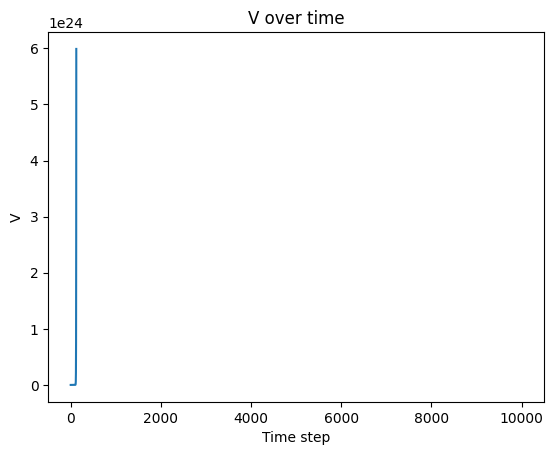

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model_path = 'Trained_Models/0818_19/E10000_TS0.05_branchConv0_trunkHidden3__proj_LamRegVol0.1_C030.0_diagQ_dim256_v2' + '/model_epoch_best.pt'
model_params = np.load(model_path.replace('model_epoch_best.pt', 'model_params.npz'), allow_pickle=True)

# Step 1: Load the read-only .npz file
loaded_data = np.load(model_path.replace('model_epoch_best.pt', 'model_params.npz'), allow_pickle=True)

# Step 2: Copy its contents into a new, editable dictionary 📋
model_params = {
    'm': 512,
    'n': 1,
    'epochs': 10000,
    'bsize': 2048,
    'lam_reg_vol': 0.1,
    'project': True,
    'tag': '',
    'c0': 30.0,
    'dt': 0.2,
    'trainable_c': False,
    'trunk_scale': 0.05,
    'diag_Q': True,
    'output_dim': 256,
    'branch_conv_channels': [],
    'branch_fc_dims': [256],
    'trunk_hidden_dims': [256, 256, 256]
}

# # Step 3: Now you can modify the new dictionary
# model_params['m'] = int(model_params['m']) 
# print(model_params)

eval_model = DeepONet(model_params).to(device)
# load the state dictionary from model_path to the eval_model
eval_model.load_state_dict(torch.load(model_path, map_location=device))

Q = eval_model.V._construct_Q().detach().cpu().numpy()
print(Q)
# Q = np.eye(512)
c = eval_model.c.detach().cpu().numpy() ** 2

data_path = 'Data/KS_data_test_l100.53_grid512_M1_T2000.0_dt0.005_dt_sample0.2_amp20.0.npz/data.npz'

# --- 2. Load Data ---
print(f"Loading data from {data_path}...")
data = np.load(data_path, allow_pickle=True)

test_traj = data['u_batch']
pred_traj = rollout_on_test(eval_model, data['x'], model_params['trunk_scale'], test_traj, device)

(10000, 512)
[0.83200582 0.90044369]


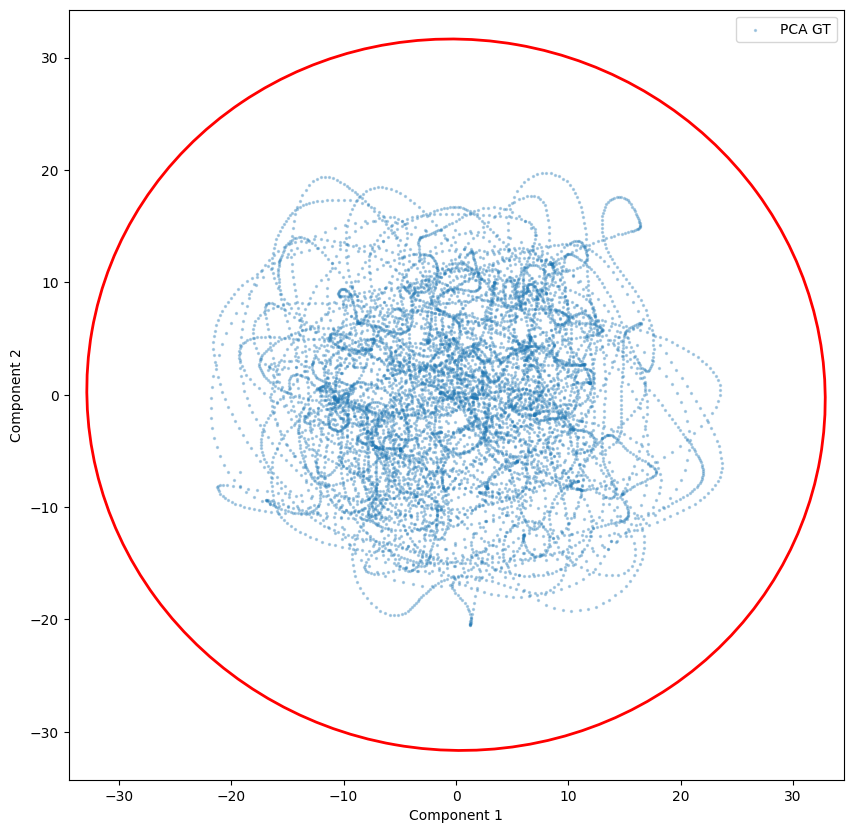

In [8]:
visualize_ellipsoid(test_traj, None, Q, c)